In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

--- Dataset Sample ---
   Age  Annual_Income  Credit_Score  Current_Debt  Prior_Defaults  \
0   56          54674           405         14868               0   
1   69          55854           727         24370               0   
2   46          66271           604         42533               0   
3   32          93688           616         30483               0   
4   60          58518           308         12466               0   

  Employment_Status  Credit_Risk  
0     Self-Employed            1  
1          Employed            0  
2        Unemployed            1  
3          Employed            0  
4          Employed            1  

--- Preprocessing Data ---

--- Training Random Forest Model ---

--- Model Evaluation ---
               precision    recall  f1-score   support

Good Risk (0)       0.98      0.93      0.96       107
 Bad Risk (1)       0.93      0.98      0.95        93

     accuracy                           0.95       200
    macro avg       0.95      0.96    

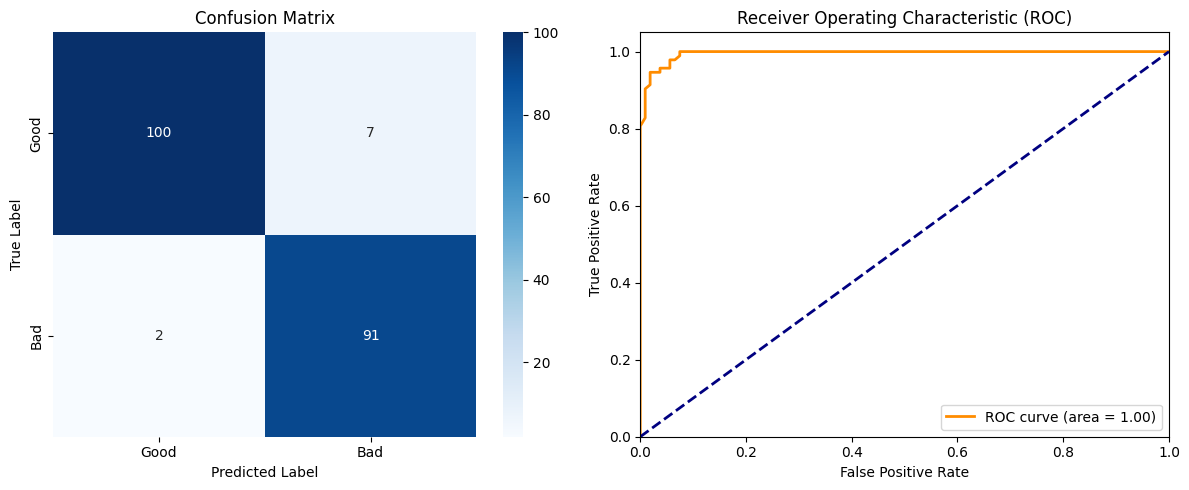

/tmp/ipykernel_1168/3540943410.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


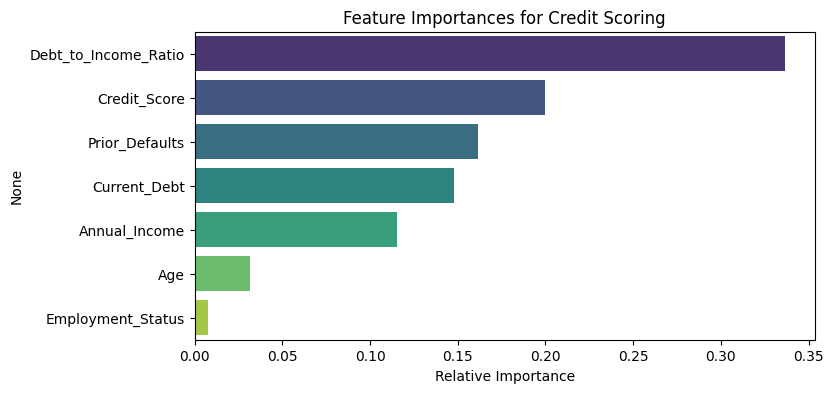

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(18, 70, size=n_samples),
    'Annual_Income': np.random.randint(20000, 120000, size=n_samples),
    'Credit_Score': np.random.randint(300, 850, size=n_samples),
    'Current_Debt': np.random.randint(0, 50000, size=n_samples),
    'Prior_Defaults': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'Employment_Status': np.random.choice(['Employed', 'Unemployed', 'Self-Employed'], size=n_samples, p=[0.7, 0.15, 0.15])
}

df = pd.DataFrame(data)

risk_score = (df['Current_Debt'] / df['Annual_Income'] * 2) + df['Prior_Defaults'] * 2 - (df['Credit_Score'] / 400)
df['Credit_Risk'] = (risk_score > -0.5).astype(int)

print("--- Dataset Sample ---")
print(df.head())


print("\n--- Preprocessing Data ---")

df['Debt_to_Income_Ratio'] = df['Current_Debt'] / df['Annual_Income']

le = LabelEncoder()
df['Employment_Status'] = le.fit_transform(df['Employment_Status'])

X = df.drop(columns=['Credit_Risk'])
y = df['Credit_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Training Random Forest Model ---")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

print("\n--- Model Evaluation ---")
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Good Risk (0)', 'Bad Risk (1)']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Feature Importances for Credit Scoring')
plt.xlabel('Relative Importance')
plt.show()